[Numerical Solution of Initial Value Problems](https://web.mit.edu/10.001/Web/Course_Notes/Differential_Equations_Notes/node2.html)

**Forward (Explict) Euler Method**

Let's denote the time at the nth time-step by tn and the computed solution at the nth time-step by $ y_n $, i.e., $y_n=y(t=t_n)$. The step size h (assumed to be constant for the sake of simplicity) is then given by $h=t_n-t_{n-1}$. Given ($t_n$, $y_n$), the forward Euler method (FE) computes $y_{n+1}$ as

$$ y_{n+1} = y_n + hf'(y_n, t_n) $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

$$ f'(y) = \frac{dy}{dt} = -ay $$
$$ y(0) = 1 $$
$$ a > 0 $$

To ensure stability in the solution, $ h < 2/a$

In [2]:
y_initial = 1
h = 0.001 # step size, h < 2/a
t_span = 3
# ODE: dy/dt = -10y

In [3]:
def ode(y, t):
    dydt = -10*y
    return dydt

In [4]:
def explictEulerIntegrator(ode, y_initial, t_span, step_size):
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    y_curr = y_initial
    sol = np.zeros((len(t), 2))
    sol[:, 0] = t
    sol[0, 1] = y_curr
    
    for i in range(1, len(t)):
        y_next = y_curr + step_size*ode(y_curr, t[i-1])
        sol[i,1] = y_next
        y_curr = y_next

    return sol

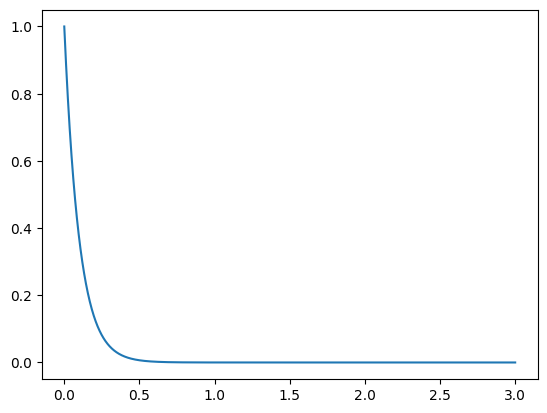

8.046069742102728e-14


In [5]:
sol = explictEulerIntegrator(ode, y_initial, t_span, h)
plt.plot(sol[:,0], sol[:,1])
plt.show()
print(sol[-1,1])

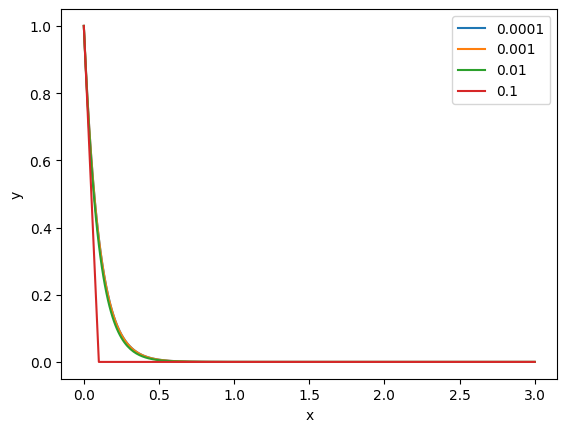

In [6]:
step_sizes = [0.0001, 0.001, 0.01, 0.1]
for h_ in step_sizes:
    sol = explictEulerIntegrator(ode, y_initial, t_span, h_)
    plt.plot(sol[:,0], sol[:,1], '-')
plt.legend(step_sizes)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

**Backward (Implicit) Euler Method**

The implicit analogue of the explicit FE method is the backward Euler (BE) method. This is based on the following Taylor series expansion
$$y_n = y(t_{n+1}-h) = y(t_{n+1})-h\frac{dy}{dt}|_{t_{n+1}}+O(h^2) $$
which gives
$$ y_{n+1} = y_n + hf'(y_{n+1}, t_{n+1}) $$

In [7]:
y_initial = 1
h = 0.001 # step size, h < 2/a
t_span = 3
# ODE: dy/dt = -10y

In [8]:
def ode(y, t):
    dydt = -10*y
    return dydt

In [9]:
def implictEulerIntegrator(ode, y_initial, t_span, step_size):
    y_curr = y_initial
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    sol = np.zeros((len(t),2))
    sol[:,0] = t
    sol[0,1] = y_curr

    for i in range(1, len(t)):
        residual = lambda y_next: y_curr + step_size*ode(y_next, t[i]) - y_next
        initial_guess = y_curr + step_size * ode(y_curr, t[i-1])
        y_next = fsolve(residual, initial_guess)[0]
        sol[i,1] = y_next
        y_curr = y_next
    
    return sol

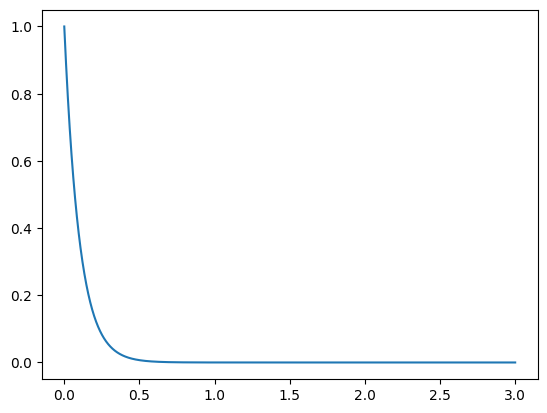

1.0861221035703651e-13


In [10]:
sol = implictEulerIntegrator(ode, y_initial, t_span, h)
plt.plot(sol[:,0], sol[:,1])
plt.show()
print(sol[-1,1])

**Runge-Kutta Methods**

Second Order Runge-Kutta Method (RK2)
1. Heun's Method
$$ \frac{dy}{dt} = f(y,t)$$
$$ f_1 = f(y_n,t_n) $$
$$ f_2 = f(y_{n+1}, t_{n+1}) = f(y_n+hf(y_n,t_n), t_n+h) = f(y_n+hf_1, t_n+h) $$
$$ y_{n+1} = y_n + \frac{h}{2}(f_1 + f_2)$$

In [11]:
y_initial = 1
h = 0.001 # step size, h < 2/a
t_span = 3
# ODE: dy/dt = -10y

In [12]:
def ode(y, t):
    dydt = -10*y
    return dydt

In [ ]:
def ode(y, t):
    dydt = -10*y
    return dydt

In [ ]:
def ode(y, t):
    dydt = -10*y
    return dydt

In [13]:
def rk2_heuns_method(ode, y_initial, t_span, step_size):
    y_n = y_initial
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    sol = np.zeros((len(t), 2))
    sol[:,0] = t
    sol[0,1] = y_n

    for i in range(1, len(t)):
        f1 = ode(y_n, t[i-1])
        f2 = ode(y_n + step_size*f1, t[i])
        y_n1 = y_n + (f1 + f2)*step_size/2
        sol[i,1] = y_n1
        y_n = y_n1
    
    return sol

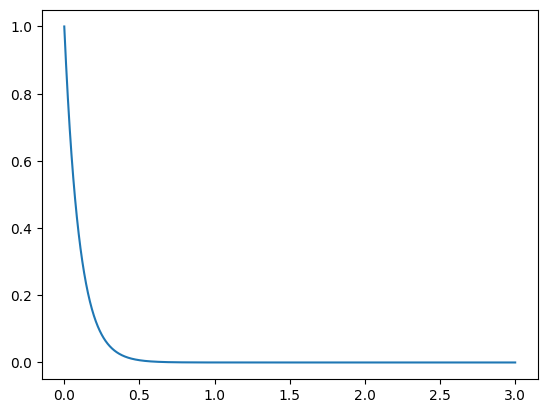

9.362338199354322e-14


In [14]:
sol = rk2_heuns_method(ode, y_initial, t_span, h)
plt.plot(sol[:,0], sol[:,1])
plt.show()
print(sol[-1,1])

2. Midpoint Method
$$ f_1 = f(y_n, t_n) $$
$$ f_2 = f(y_n + \frac{h}{2}f_1, t_n + \frac{h}{2}) $$
$$ y_{n+1} = y_n + hf_2 $$

In [15]:
def rk2_midpoint_method(ode, y_initial, t_span, step_size):
    y_n = y_initial
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    sol = np.zeros((len(t), 2))
    sol[:,0] = t
    sol[0,1] = y_n

    for i in range(1, len(t)):
        f1 = ode(y_n, t[i-1])
        f2 = ode(y_n + step_size*f1/2, t[i-1]+step_size/2)
        y_n1 = y_n + step_size*f2
        sol[i,1] = y_n1
        y_n = y_n1
    
    return sol

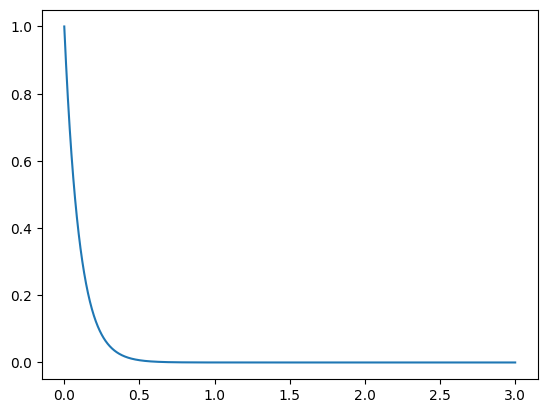

9.362338199354315e-14


In [16]:
sol = rk2_midpoint_method(ode, y_initial, t_span, h)
plt.plot(sol[:,0], sol[:,1])
plt.show()
print(sol[-1,1])

Fourth Order Runge-Kutta Method
$$ \frac{dy}{dt} = f(y,t) $$
$$ f_1 = f(y_n, t_n)$$
$$ f_2 = f(y_n + \frac{h}{2}f_1, t_n + \frac{h}{2})$$
$$ f_3 = f(y_n + \frac{h}{2}f_2, t_n + \frac{h}{2})$$
$$ f_4 = f(y_n + hf_3, t_n + h) $$
$$ y_{n+1} = y_n + \frac{h}{6}\left(f_1 + 2f_2 + 2f_3 + f_4\right)$$

In [26]:
def rk4(ode, y_initial, t_span, step_size):
    y_n = y_initial
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    sol = np.zeros((len(t), len(np.array([y_n])) + 1))
    sol[:,0] = t
    sol[0,1] = y_n

    for i in range(1, len(t)):
        f1 = ode(y_n, t[i-1])
        f2 = ode(y_n + step_size*f1/2, t[i-1] + step_size/2)
        f3 = ode(y_n + step_size*f2/2, t[i-1] + step_size/2)
        f4 = ode(y_n + step_size*f3, t[i])

        y_n1 = y_n + (f1 + 2*f2 + 2*f3 + f4)*step_size/6
        sol[i,1] = y_n1
        y_n = y_n1

    return sol

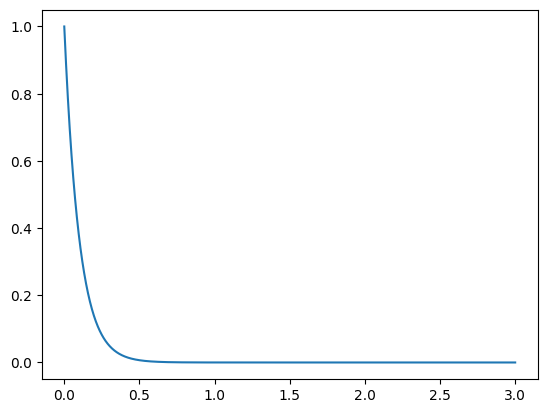

9.357622992430001e-14


In [27]:
sol = rk4(ode, y_initial, t_span, h)
plt.plot(sol[:,0], sol[:,1])
plt.show()
print(sol[-1,1])

**Adams Method**
$$ y_{n+1} = y_n + \int_{t_n}^{t_{n+1}}\frac{dy}{dt}dt = y_n + \int_{t_n}^{t_{n+1}}f(y,t)dt $$
There are two types of Adams methods, the explicit and the implicit types. The explicit type is called the Adams-Bashforth (AB) methods and the implicit type is called the Adams-Moulton (AM) methods.

*Adam-Bashforth methods:*
$$ k=1: y_{n+1} = y_n + hf_n \text{ (explicit Euler Method)}$$ 
$$ k=2: y_{n+1} = y_n + h\left(\frac{3}{2}f_n - \frac{1}{2}f_{n-1}\right)$$
$$ k=3: y_{n+1} = y_n + h\left(\frac{23}{12}f_n - \frac{16}{12}f_{n-1}+\frac{5}{12}f_{n-2} \right)$$

In [122]:
y_initial = 1
h = 0.05 # step size, h < 2/a
t_span = 3
# ODE: dy/dt = -10y

In [114]:
def ode(y, t):
    dydt = -10*y
    return dydt

In [115]:
def AB_k2_method(ode, y_initial, t_span, step_size):
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    y_n_1 = y_initial # y0
    y_n = y_n_1 + step_size*ode(y_n_1, t[0]) #y1 calculated using Euler's method
    sol = np.zeros((len(t), len(np.array([y_n])) + 1))
    sol[:,0] = t
    sol[0,1] = y_n_1
    sol[1,1] = y_n

    for i in range(2, len(t)):
        f_n_1 = ode(y_n_1, t[i-2])
        f_n = ode(y_n, t[i-1])
        y_n1 = y_n + step_size*(3*f_n/2 - f_n_1/2) # y_n+1
        sol[i,1] = y_n1
        y_n_1 = y_n
        y_n = y_n1
    
    return sol

In [116]:
def AB_k3_method(ode, y_initial, t_span, step_size):
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    y_n_2 = y_initial # y0
    y_n_1 = y_n_2 + step_size*ode(y_n_2, t[0]) # y1 calculated using Euler's method
    y_n = y_n_1 + step_size*ode(y_n_1, t[1]) # y2
    sol = np.zeros((len(t), len(np.array([y_n])) + 1))
    sol[:,0] = t
    sol[0,1] = y_n_2
    sol[1,1] = y_n_1
    sol[2,1] = y_n

    for i in range(3, len(t)):
        f_n_2 = ode(y_n_2, t[i-3])
        f_n_1 = ode(y_n_1, t[i-2])
        f_n = ode(y_n, t[i-1])
        y_n1 = y_n + step_size*(23*f_n/12 - 16*f_n_1/12 + 5*f_n_2/12) # y_n+1
        sol[i,1] = y_n1
        y_n_2 = y_n_1
        y_n_1 = y_n
        y_n = y_n1
    
    return sol

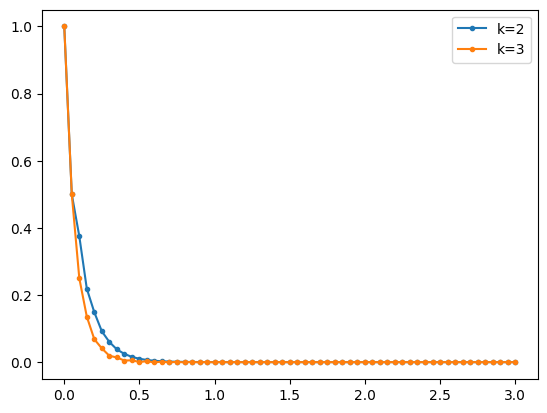

In [123]:
sol_k2 = AB_k2_method(ode, y_initial, t_span, h)
sol_k3 = AB_k3_method(ode, y_initial, t_span, h)
plt.plot(sol_k2[:,0], sol_k2[:,1], '.-')
plt.plot(sol_k3[:,0], sol_k3[:,1], '.-')
plt.legend(['k=2', 'k=3'])
plt.show()

*Adams-Moulton methods*

$$ k=0: y_{n+1} = y_n + hf_{n+1} \text{ (implicit Euler method)}$$
$$ k=1: y_{n+1} = y_n + h\left(\frac{1}{2}f_{n+1} + \frac{1}{2}f_n\right) \text{ (Trapezoidal rule)} $$
$$ k=2: y_{n+1} = y_n + h\left(\frac{5}{12}f_{n+1} + \frac{8}{12}f_n - \frac{1}{12}f_{n-1}\right) $$
$$ k=3: y_{n+1} = y_n + h\left(\frac{9}{24}f_{n+1} + \frac{19}{24}f_n - \frac{5}{24}f_{n-1} + \frac{1}{24}f_{n-2}\right) $$


In [131]:
y_initial = 1
h = 0.05 # step size, h < 2/a
t_span = 3
# ODE: dy/dt = -10y

In [130]:
def ode(y, t):
    dydt = -y**2
    return dydt

In [126]:
def AM_k1_method(ode, y_initial, t_span, step_size):
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    y_n = y_initial
    sol = np.zeros((len(t), len(np.array([y_n])) + 1))
    sol[:,0] = t
    sol[0,1] = y_n

    for i in range(1, len(t)):
        f_n = ode(y_n, t[i-1])
        residual = lambda y_n1: y_n + 0.5*step_size*(ode(y_n1, t[i]) + f_n) - y_n1
        initial_guess = y_n + step_size*(ode(y_n, t[i-1])) # explicit euler
        y_n1 = fsolve(residual, initial_guess)[0]
        sol[i,1] = y_n1
        y_n = y_n1
    
    return sol

In [127]:
def AM_k2_method(ode, y_initial, t_span, step_size):
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    y_n_1 = y_initial
    # y_n = y_n_1 + step_size*(ode(y_n_1, t[0]))
    residual = lambda y_n: y_n_1 + step_size*ode(y_n, t[1]) - y_n
    initial_guess = y_n_1 + step_size*ode(y_n_1, t[0])
    y_n = fsolve(residual, initial_guess)[0]

    sol = np.zeros((len(t), len(np.array([y_n])) + 1))
    sol[:,0] = t
    sol[0,1] = y_n_1
    sol[1,1] = y_n

    for i in range(2, len(t)):
        f_n_1 = ode(y_n_1, t[i-2])
        f_n = ode(y_n, t[i-1])
        residual = lambda y_n1: y_n + step_size*(5*ode(y_n1, t[i])/12 + 8*f_n/12 - f_n_1/12) - y_n1
        initial_guess = y_n + step_size*(ode(y_n, t[i-1]))
        y_n1 = fsolve(residual, initial_guess)[0]
        sol[i,1] = y_n1
        y_n_1 = y_n
        y_n = y_n1
    
    return sol

In [128]:
def AM_k3_method(ode, y_initial, t_span, step_size):
    t = np.linspace(0, t_span, int(t_span/step_size + 1))
    y_n_2 = y_initial
    
    residual = lambda y_n_1: y_n_2 + step_size*ode(y_n_1, t[1]) - y_n_1
    initial_guess = y_n_2 + step_size*ode(y_n_2, t[0])
    y_n_1 = fsolve(residual, initial_guess)[0]

    residual = lambda y_n: y_n_1 + step_size*ode(y_n, t[2]) - y_n
    initial_guess = y_n_1 + step_size*ode(y_n_1, t[1])
    y_n = fsolve(residual, initial_guess)[0]

    sol = np.zeros((len(t), len(np.array([y_n])) + 1))
    sol[:,0] = t
    sol[0,1] = y_n_2
    sol[1,1] = y_n_1
    sol[2,1] = y_n

    for i in range(3, len(t)):
        f_n_2 = ode(y_n_2, t[i-3])
        f_n_1 = ode(y_n_1, t[i-2])
        f_n = ode(y_n, t[i-1])
        residual = lambda y_n1: y_n + step_size*(9*ode(y_n1, t[i])/24 + 19*f_n/24 - 5*f_n_1/24 + f_n_2/24) - y_n1
        initial_guess = y_n + step_size*(ode(y_n, t[i-1]))
        y_n1 = fsolve(residual, initial_guess)[0]
        sol[i,1] = y_n1
        y_n_2 = y_n_1
        y_n_1 = y_n
        y_n = y_n1
    
    return sol

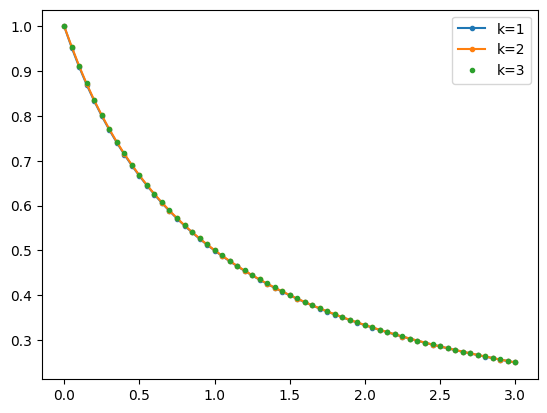

In [132]:
sol_k1 = AM_k1_method(ode, y_initial, t_span, h)
sol_k2 = AM_k2_method(ode, y_initial, t_span, h)
sol_k3 = AM_k3_method(ode, y_initial, t_span, h)
plt.plot(sol_k1[:,0], sol_k1[:,1], '.-')
plt.plot(sol_k2[:,0], sol_k2[:,1], '.-')
plt.plot(sol_k3[:,0], sol_k3[:,1], '.')
plt.legend(['k=1', 'k=2', 'k=3'])
plt.show()